In [58]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import pickle

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import MeanShift

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

from validclust import dunn

df = pd.read_excel(r"C:\Users\WELCOME\Downloads\CLUSTERING\data\application_test.xlsx",nrows=5000)

df = df.copy()

X = df[['AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS']].copy()

X = X.fillna(X.median())


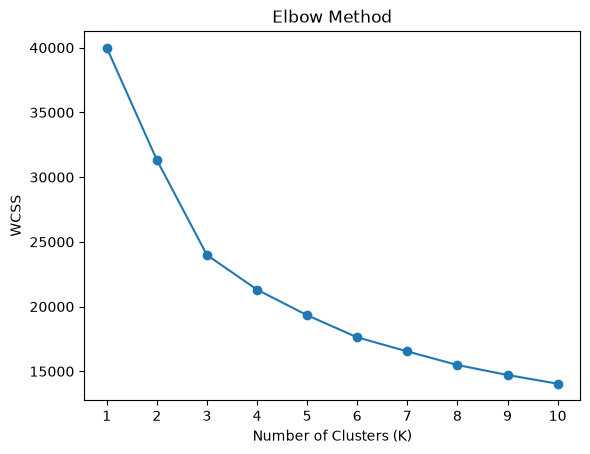

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k,random_state=42,n_init=10)

    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Elbow Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.show()

In [60]:
# ============================================================
# 1. K MEANS
# ============================================================

km = KMeans(n_clusters=5,random_state=42)

km_labels = km.fit_predict(X)

print("\n==============================")
print("K MEANS")
print("==============================")

print("Unique Clusters:", np.unique(km_labels))

print("Total Rows:", len(km_labels))

df = df.copy()
df['KMeans cluster'] = km_labels

print(df['KMeans cluster'].value_counts())


# Silhouette Score

km_silhouette = silhouette_score(X,km_labels,metric='euclidean')

print("Silhouette Score:", km_silhouette)


# Dunn Index

km_distance = pairwise_distances(X,metric='euclidean')

km_dunn = dunn(km_distance,km_labels)

print("Dunn Index:", km_dunn)



# Save Model

with open('kmeans_model_v1.pkl', 'wb') as file:
    pickle.dump(km, file)



K MEANS
Unique Clusters: [0 1 2 3 4]
Total Rows: 5000
KMeans cluster
3    2025
0    1612
4     747
1     415
2     201
Name: count, dtype: int64
Silhouette Score: 0.44023001818374796
Dunn Index: 0.006596118244454487


In [61]:
cat = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
print(cat)

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [62]:
# ============================================================
# 2. K MODES
# ============================================================

X_cat = df[['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY','NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','ORGANIZATION_TYPE','HOUSETYPE_MODE']].copy()

X_cat = X_cat.fillna('Missing').astype(str)

kmod = KModes(n_clusters=5,init='Huang', random_state=42)

kmod_labels = kmod.fit_predict(X_cat)


print("\n==============================")
print("K MODES")
print("==============================")

print("Unique Clusters:", np.unique(kmod_labels))

print("Total Rows:", len(kmod_labels))

df = df.copy()
df['KModes cluster'] = kmod_labels

print(df['KModes cluster'].value_counts())


# Encode categorical data for validation

X_cat_encoded = pd.get_dummies(X_cat).astype(int)


# Silhouette Score

kmod_silhouette = silhouette_score(X_cat_encoded,kmod_labels,metric='hamming')

print("Silhouette Score:", kmod_silhouette)


# Dunn Index
sample_size = min(3000, len(X_cat_encoded))
sample_idx = np.random.choice(len(X_cat_encoded), size=sample_size, replace=False)

X_sample = X_cat_encoded.iloc[sample_idx]
labels_sample = kmod_labels[sample_idx]

kmod_distance = pairwise_distances(X_sample,metric='hamming')

kmod_dunn = dunn(kmod_distance,labels_sample)

print("Dunn Index:", kmod_dunn)


# Save Model

with open('kmodes_model_v1.pkl', 'wb') as file:
    pickle.dump(kmod, file)



K MODES
Unique Clusters: [0 1 2 3 4]
Total Rows: 5000
KModes cluster
1    1565
0    1337
4    1153
2     597
3     348
Name: count, dtype: int64
Silhouette Score: 0.19454939233825286
Dunn Index: 0.125


In [63]:
# ============================================================
# 3. AGGLOMERATIVE CLUSTERING
# ============================================================

ag = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')

ag_labels = ag.fit_predict(X)


print("\n==============================")
print("AGGLOMERATIVE")
print("==============================")

print("Unique Clusters:", np.unique(ag_labels))

print("Total Rows:", len(ag_labels))

df = df.copy()
df['Agglomerative cluster'] = ag_labels

print(df['Agglomerative cluster'].value_counts())


# Silhouette Score

ag_silhouette = silhouette_score(X,ag_labels,metric='euclidean')

print("Silhouette Score:", ag_silhouette)


# Dunn Index

ag_distance = pairwise_distances(X,metric='euclidean')

ag_dunn = dunn(ag_distance,ag_labels)

print("Dunn Index:", ag_dunn)


# Save Model

with open('Agglomerative_model_v1.pkl', 'wb') as file:
    pickle.dump(ag, file)



AGGLOMERATIVE
Unique Clusters: [0 1 2 3 4]
Total Rows: 5000
Agglomerative cluster
1    2053
0    1261
3     906
4     521
2     259
Name: count, dtype: int64
Silhouette Score: 0.4568583111534463
Dunn Index: 0.00986252292583955


In [64]:
# ============================================================
# 4. K PROTOTYPES
# ============================================================

X_kp = df[[
    'AMT_CREDIT','AMT_ANNUITY','AMT_GOODS_PRICE','DAYS_BIRTH',
    'DAYS_EMPLOYED','DAYS_REGISTRATION','DAYS_ID_PUBLISH','CNT_FAM_MEMBERS',
    'NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY',
    'NAME_FAMILY_STATUS','NAME_HOUSING_TYPE','ORGANIZATION_TYPE','HOUSETYPE_MODE'
    ]].copy()


numerical_columns = ['AMT_CREDIT',
                     'AMT_ANNUITY',
                     'AMT_GOODS_PRICE',
                     'DAYS_BIRTH',
                     'DAYS_EMPLOYED',
                     'DAYS_REGISTRATION',
                     'DAYS_ID_PUBLISH',
                     'CNT_FAM_MEMBERS']

categorical_columns = ['NAME_CONTRACT_TYPE',
                       'CODE_GENDER',
                       'FLAG_OWN_CAR',
                       'FLAG_OWN_REALTY',
                       'NAME_FAMILY_STATUS',
                       'NAME_HOUSING_TYPE',
                       'ORGANIZATION_TYPE',
                       'HOUSETYPE_MODE']


X_kp[numerical_columns] = (X_kp[numerical_columns].fillna(X_kp[numerical_columns].median()))

X_kp[categorical_columns] = (X_kp[categorical_columns].fillna('Missing').astype(str))

kp = KPrototypes(n_clusters=5, init='Huang', random_state=42)
kp_labels = kp.fit_predict(X_kp.values, categorical=[8, 9, 10, 11, 12, 13, 14, 15])

print("\n==============================")
print("K PROTOTYPES")
print("==============================")

print("Unique Clusters:", np.unique(kp_labels))

print("Total Rows:", len(kp_labels))

df = df.copy()
df['KPrototypes cluster'] = kp_labels

print(df['KPrototypes cluster'].value_counts())


# Encode categorical columns for validation

X_kp_encoded = pd.get_dummies(X_kp,columns=categorical_columns).astype(float)


# Silhouette Score

kp_silhouette = silhouette_score(X_kp_encoded,kp_labels,metric='euclidean')

print("Silhouette Score:", kp_silhouette)


# Dunn Index

kp_distance = pairwise_distances(X_kp_encoded,metric='euclidean')

kp_dunn = dunn(kp_distance,kp_labels)

print("Dunn Index:", kp_dunn)


# Save Model

with open('kprototypes_model_v1.pkl', 'wb') as file:
    pickle.dump(kp, file)



K PROTOTYPES
Unique Clusters: [0 1 2 3 4]
Total Rows: 5000
KPrototypes cluster
0    1640
3    1391
2     983
4     767
1     219
Name: count, dtype: int64
Silhouette Score: 0.525948145955177
Dunn Index: 0.006207861729391763


In [65]:
# ============================================================
# 5. DBSCAN
# ============================================================

# DBSCAN needs scaled numerical features because the raw data mixes
# very different units (credit amounts vs. days) and a small eps
# in raw units marks almost everything as noise.
scaler_db = StandardScaler()
X_db_scaled = scaler_db.fit_transform(X)

db = DBSCAN(eps=2.5, min_samples=10, metric='euclidean')
db_labels = db.fit_predict(X_db_scaled)

print("\n==============================")
print("DBSCAN")
print("==============================")

print("Unique Clusters:", np.unique(db_labels))
print("Total Rows:", len(db_labels))

df = df.copy()
df['DBSCAN cluster'] = db_labels

print(df['DBSCAN cluster'].value_counts())


# Remove noise (-1) before validation
db_mask = db_labels != -1
X_db = X_db_scaled[db_mask]
db_valid_labels = db_labels[db_mask]

if len(np.unique(db_valid_labels)) > 1:

    # Silhouette Score
    db_silhouette = silhouette_score(X_db, db_valid_labels, metric='euclidean')
    print("Silhouette Score:", db_silhouette)

    # Dunn Index
    db_distance = pairwise_distances(X_db, metric='euclidean')
    db_dunn = dunn(db_distance, db_valid_labels)
    print("Dunn Index:", db_dunn)

else:
    print("Silhouette Score cannot be calculated")
    print("Dunn Index cannot be calculated")


# Save Model
with open('dbscan_model_v1.pkl', 'wb') as file:
    pickle.dump(db, file)



DBSCAN
Unique Clusters: [-1  0  1]
Total Rows: 5000
DBSCAN cluster
 0    4031
 1     960
-1       9
Name: count, dtype: int64
Silhouette Score: 0.2765021425032808
Dunn Index: 0.23336644019120734


In [68]:
# ============================================================
# 6. MEAN SHIFT
# ============================================================

ms = MeanShift()

ms_labels = ms.fit_predict(X)


print("\n==============================")
print("MEAN SHIFT")
print("==============================")

print("Unique Clusters:", np.unique(ms_labels))

print("Total Rows:", len(ms_labels))

df = df.copy()
df['MeanShift cluster'] = ms_labels

print(df['MeanShift cluster'].value_counts())


if len(np.unique(ms_labels)) > 1:

    # Silhouette Score

    ms_silhouette = silhouette_score(
        X,
        ms_labels,
        metric='euclidean'
    )

    print("Silhouette Score:", ms_silhouette)


    # Dunn Index

    ms_distance = pairwise_distances(
        X,
        metric='euclidean'
    )

    ms_dunn = dunn(
        ms_distance,
        ms_labels
    )

    print("Dunn Index:", ms_dunn)

else:

    print("Silhouette Score cannot be calculated")

    print("Dunn Index cannot be calculated")


# Save Model

with open('meanshift_model_v1.pkl', 'wb') as file:
    pickle.dump(ms, file)



# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n==============================")
print("ALL MODELS COMPLETED")
print("==============================")


summary_columns = [
    'KMeans cluster',
    'KModes cluster',
    'Agglomerative cluster',
    'KPrototypes cluster',
    'DBSCAN cluster',
    'MeanShift cluster'
]
summary_columns = [col for col in summary_columns if col in df.columns]

print(df[summary_columns].head())



MEAN SHIFT
Unique Clusters: [0 1 2 3 4]
Total Rows: 5000
MeanShift cluster
0    3444
1     883
2     547
3     112
4      14
Name: count, dtype: int64
Silhouette Score: 0.3878851444636136
Dunn Index: 0.008027222307863928

ALL MODELS COMPLETED
   KMeans cluster  KModes cluster  Agglomerative cluster  KPrototypes cluster  \
0               0               1                      0                    3   
1               3               0                      1                    0   
2               4               0                      3                    3   
3               2               2                      2                    1   
4               4               0                      3                    3   

   DBSCAN cluster  MeanShift cluster  
0               0                  0  
1               0                  0  
2               0                  0  
3               0                  3  
4               0                  0  


In [67]:
# ============================================================
# PICKLE FILES CREATED
# ============================================================

print("\nPickle Files Created:")

print("kmeans_model_v1.pkl")
print("kmodes_model_v1.pkl")
print("agglomerative_model_v1.pkl")
print("kprototypes_model_v1.pkl")
print("dbscan_model_v1.pkl")
print("meanshift_model_v1.pkl")


Pickle Files Created:
kmeans_model_v1.pkl
kmodes_model_v1.pkl
agglomerative_model_v1.pkl
kprototypes_model_v1.pkl
dbscan_model_v1.pkl
meanshift_model_v1.pkl
